## Revision inicial del dataset

En esta primera fase se analiza la estructura general del dataset para comprobar si es adecuado para construir una solucion de mantenimiento predictivo.

El objetivo es verificar el volumen de datos, los tipos de variables disponibles, la existencia de valores nulos o duplicados y la distribucion inicial de la variable objetivo.

Desde el punto de vista de negocio, esta revision permite validar si los datos contienen informacion suficiente para estudiar el riesgo de fallo de una maquina antes de avanzar hacia limpieza, analisis exploratorio y modelado.


In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv("../data/raw/ai4i2020.csv")


## Diccionario de variables

| Variable | Significado | Uso inicial |
|---|---|---|
| `UDI` | Identificador unico del registro | No se usara como predictora |
| `Product ID` | Identificador del producto o instancia | No se usara como predictora |
| `Type` | Tipo o categoria del producto/maquina | Variable predictora categorica |
| `Air temperature [K]` | Temperatura ambiente medida en Kelvin | Variable predictora numerica |
| `Process temperature [K]` | Temperatura del proceso medida en Kelvin | Variable predictora numerica |
| `Rotational speed [rpm]` | Velocidad de rotacion en revoluciones por minuto | Variable predictora numerica |
| `Torque [Nm]` | Fuerza de giro o par motor aplicado por la maquina | Variable predictora numerica |
| `Tool wear [min]` | Desgaste acumulado de la herramienta en minutos | Variable predictora numerica |
| `Machine failure` | Indica si la maquina falla o no | Variable objetivo |
| `TWF` | Fallo por desgaste de herramienta | Solo analisis, no predictor principal |
| `HDF` | Fallo por disipacion de calor | Solo analisis, no predictor principal |
| `PWF` | Fallo de potencia | Solo analisis, no predictor principal |
| `OSF` | Fallo por sobreesfuerzo | Solo analisis, no predictor principal |
| `RNF` | Fallo aleatorio | Solo analisis, no predictor principal |


**Nota sobre fuga de informacion:** Las columnas `TWF`, `HDF`, `PWF`, `OSF` y `RNF` indican tipos especificos de fallo. Aunque son utiles para entender el dataset, no se usaran como variables predictoras del modelo principal porque contienen informacion demasiado cercana al resultado que queremos predecir.

En un caso real, el objetivo seria anticipar si una maquina puede fallar antes de conocer el diagnostico concreto del fallo. Por este motivo, estas columnas se reservaran para analisis complementario y no para el entrenamiento del modelo binario principal.


In [22]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [9]:
df.duplicated()


0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [13]:
df.columns 

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [14]:
df.dtypes 

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [15]:
df.describe()


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [16]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [17]:
df["Machine failure"].value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

## Interpretacion inicial de variables

El dataset contiene variables identificadoras, variables operativas, una variable objetivo y columnas asociadas a tipos especificos de fallo.

Las variables operativas principales son `Type`, `Air temperature [K]`, `Process temperature [K]`, `Rotational speed [rpm]`, `Torque [Nm]` y `Tool wear [min]`. Estas variables describen condiciones de funcionamiento de la maquina y son las candidatas principales para construir el modelo predictivo.

La variable `Machine failure` sera la variable objetivo, ya que indica si la maquina ha fallado o no.

Las columnas `UDI` y `Product ID` se consideran identificadores, por lo que no se utilizaran como predictoras. Las columnas `TWF`, `HDF`, `PWF`, `OSF` y `RNF` representan tipos concretos de fallo y no se incluiran en el modelo principal para evitar fuga de informacion.

Decision inicial: el modelo se construira usando variables operativas reales y excluyendo identificadores o variables que puedan contener informacion directa del fallo.


In [23]:
# Aquí clasificamos las columnas. Si una columna tiene casi tantos valores únicos como filas, probablemente es un identificador.
df.nunique()
 

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

In [24]:
df.nunique().sort_values()
 

PWF                            2
HDF                            2
RNF                            2
OSF                            2
TWF                            2
Machine failure                2
Type                           3
Process temperature [K]       82
Air temperature [K]           93
Tool wear [min]              246
Torque [Nm]                  577
Rotational speed [rpm]       941
Product ID                 10000
UDI                        10000
dtype: int64

## Valores unicos por columna

El analisis de valores unicos confirma la naturaleza de las variables del dataset.

`UDI` y `Product ID` presentan un valor diferente por registro, lo que refuerza que son identificadores y no variables utiles para generalizar patrones de fallo.

`Type` tiene tres categorias, por lo que se tratara como variable categorica. Las variables `Machine failure`, `TWF`, `HDF`, `PWF`, `OSF` y `RNF` son binarias.

Desde el punto de vista del modelado, esta revision ayuda a decidir que variables requieren codificacion, que variables deben excluirse y cuales pueden utilizarse directamente como variables numericas.


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
target_counts = df["Machine failure"].value_counts()
target_counts


Machine failure
0    9661
1     339
Name: count, dtype: int64

In [29]:
target_percentages = df["Machine failure"].value_counts(normalize=True) * 100
target_percentages


Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

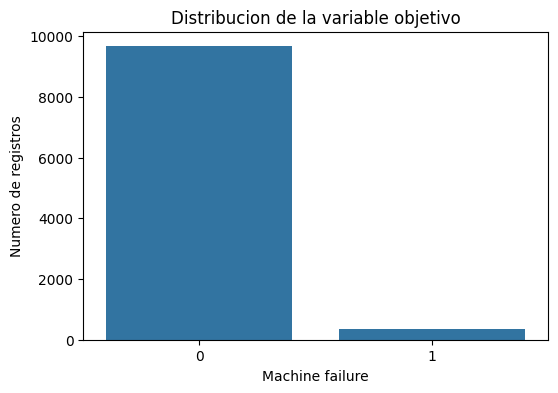

In [30]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Machine failure"
)

plt.title("Distribucion de la variable objetivo")
plt.xlabel("Machine failure")
plt.ylabel("Numero de registros")
plt.show()


En este grafico, el eje X representa las dos clases de la variable objetivo: `0` para maquinas sin fallo y `1` para maquinas con fallo.

El eje Y representa el numero de registros que pertenecen a cada clase. Este valor no es una columna del dataset, sino el resultado de contar cuantas veces aparece cada categoria en `Machine failure`.


## Distribucion de la variable objetivo

La variable `Machine failure` esta fuertemente desbalanceada: la mayoria de registros corresponden a maquinas sin fallo y solo una pequena parte corresponde a maquinas con fallo.

Este comportamiento es realista en un contexto industrial, ya que los fallos suelen ser eventos poco frecuentes. Sin embargo, desde el punto de vista de negocio, son precisamente los casos mas importantes: una averia no detectada puede provocar paradas de produccion, costes de reparacion y retrasos operativos.

Por este motivo, la evaluacion del modelo no debera basarse solo en `accuracy`. Un modelo que prediga siempre "no fallo" podria obtener una precision global alta, pero no aportaria valor real si no identifica las maquinas con riesgo.

En fases posteriores se priorizaran metricas como `recall`, `precision`, `F1-score`, `ROC AUC` y matriz de confusion, prestando especial atencion a la deteccion de la clase fallo.

Decision para el proyecto: estas variables se mantendran como candidatas principales para el modelo, y en fases posteriores se evaluara si necesitan escalado o tratamiento de valores extremos segun el tipo de algoritmo utilizado.



In [31]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

numeric_features


['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]']

In [32]:
df[numeric_features].describe()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


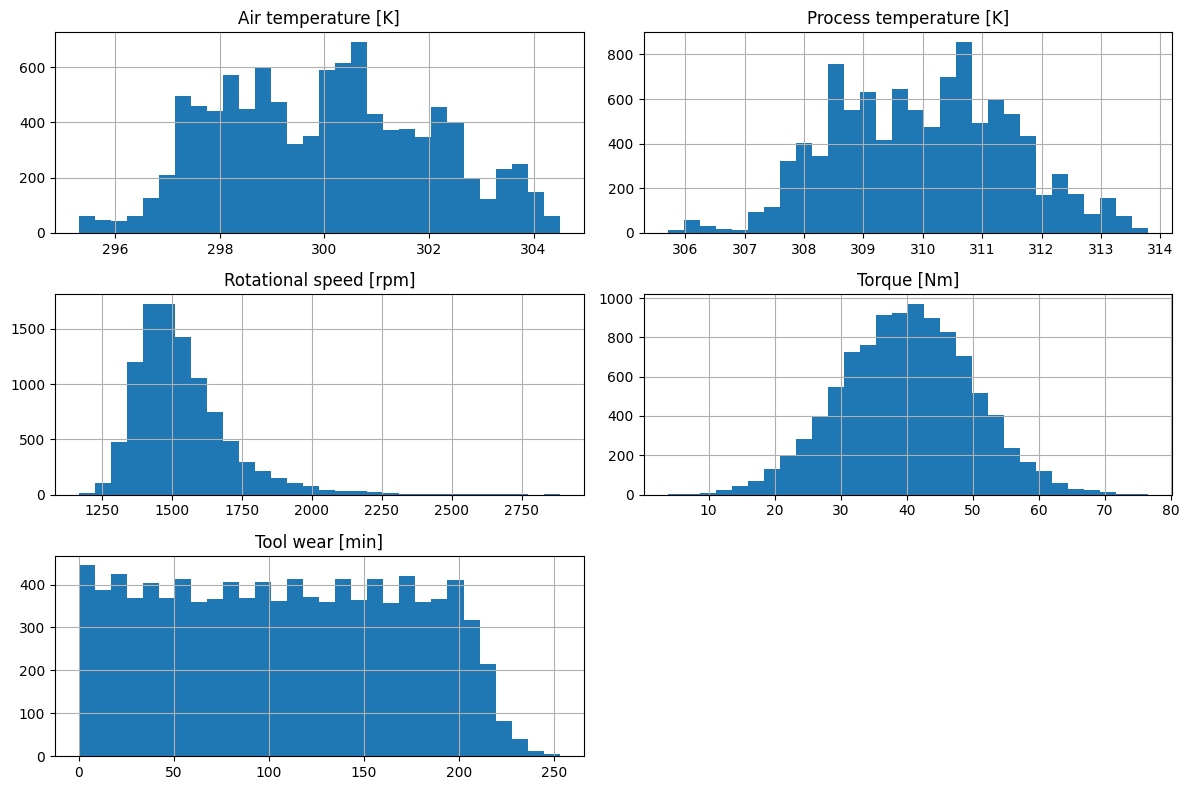

In [33]:
df[numeric_features].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()


## Distribucion de variables numericas

Se analizan las variables numericas operativas del dataset: temperatura ambiente, temperatura de proceso, velocidad de rotacion, torque y desgaste de herramienta.

Los histogramas permiten observar el rango, la forma de la distribucion y posibles valores extremos en cada variable.

Este paso es importante porque algunos modelos de Machine Learning son sensibles a la escala y distribucion de las variables. Por ejemplo, modelos como KNN, SVM o Regresion Logistica suelen beneficiarse de escalado, mientras que modelos basados en arboles como Decision Tree o Random Forest son menos sensibles a la escala.


## Comparacion de variables numericas segun fallo

En esta seccion se comparan las variables operativas entre maquinas sin fallo y maquinas con fallo.

El objetivo es identificar si existen diferencias en temperatura, velocidad de rotacion, torque o desgaste que puedan ayudar a anticipar un fallo.

Desde el punto de vista de negocio, estas diferencias son relevantes porque pueden convertirse en senales tempranas para priorizar tareas de mantenimiento.


In [34]:
df.groupby("Machine failure")[numeric_features].mean()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


In [35]:
df.groupby("Machine failure")[numeric_features].agg(["mean", "median", "std"])


Air temperature [K]                  Process temperature [K]  \
                               mean median       std                    mean   
Machine failure                                                                
0                        299.973999  300.0  1.990748              309.995570   
1                        300.886431  301.6  2.071473              310.290265   

                                 Rotational speed [rpm]                      \
                median       std                   mean  median         std   
Machine failure                                                               
0                310.0  1.486846            1540.260014  1507.0  167.394734   
1                310.4  1.363686            1496.486726  1365.0  384.943547   

                Torque [Nm]                   Tool wear [min]         \
                       mean median        std            mean median   
Machine failure                                                        
0                 39.629655   39.9   9.472080      106.693717  107.0   
1                 50.168142   53.7  16.374498      143.781711  165.0   

                            
                       std  
Machine failure             
0                62.945790  
1                72.759876

**Interpretacion:** Las maquinas con fallo presentan, de media, mayor torque y mayor desgaste de herramienta que las maquinas sin fallo. Tambien muestran una velocidad de rotacion media inferior, aunque esta variable presenta mayor variabilidad.

**Implicacion de negocio:** Estos patrones sugieren que el esfuerzo mecanico y el desgaste acumulado pueden ser senales relevantes para priorizar tareas de mantenimiento predictivo.


## Comparacion visual segun fallo

Ahora comparamos las variables numericas separando las maquinas sin fallo y con fallo.

Esto nos ayuda a ver si las maquinas que fallan tienen valores diferentes en temperatura, velocidad, torque o desgaste.


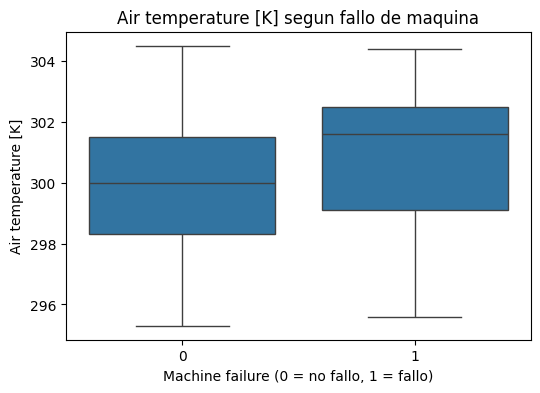

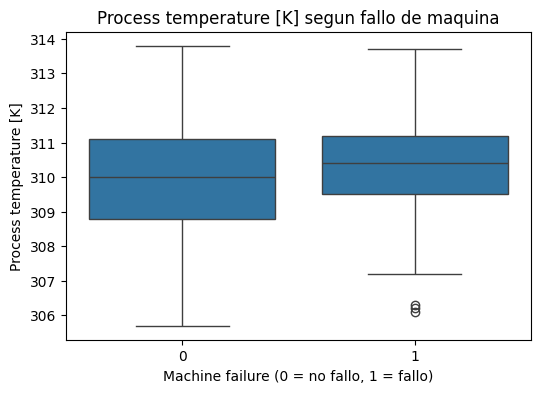

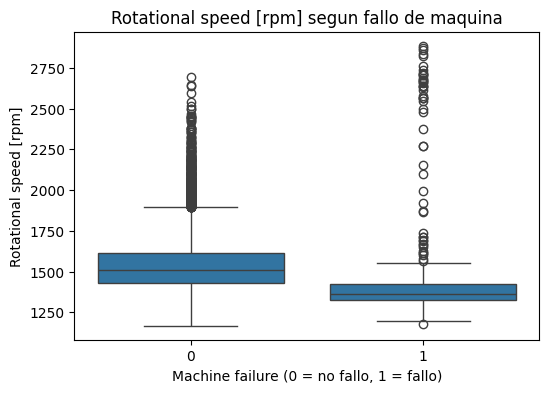

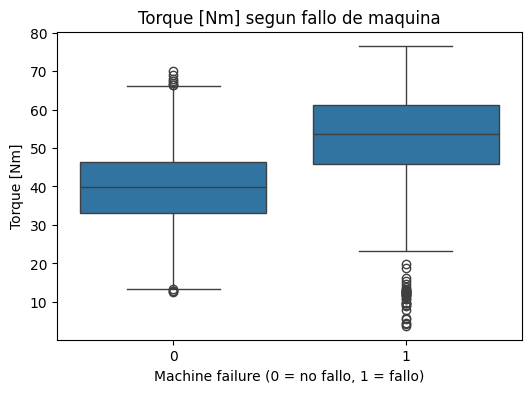

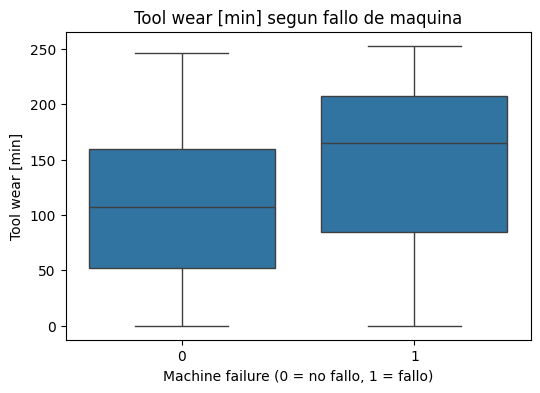

In [37]:
for feature in numeric_features:
    plt.figure(figsize=(6, 4))
    
    sns.boxplot(
        data=df,
        x="Machine failure",
        y=feature
    )
    
    plt.title(f"{feature} segun fallo de maquina")
    plt.xlabel("Machine failure (0 = no fallo, 1 = fallo)")
    plt.ylabel(feature)
    plt.show()


**Interpretacion:** En los boxplots se observa que las maquinas con fallo suelen tener valores algo mas altos de temperatura ambiente, aunque la diferencia no es muy grande.

La temperatura de proceso no muestra una separacion tan clara entre maquinas con y sin fallo. Aun asi, aparecen algunos valores bajos que conviene tener en cuenta durante el analisis.

La velocidad de rotacion presenta bastante variabilidad y varios valores extremos en ambos grupos. Esto indica que por si sola puede no explicar bien el fallo, pero podria aportar informacion si se combina con otras variables.

En el caso del torque, las maquinas con fallo tienden a mostrar valores mas altos, lo que puede indicar mayor esfuerzo mecanico.

El desgaste de herramienta es una de las variables que se interpreta de forma mas clara: las maquinas con fallo suelen tener mas minutos de uso acumulado.

**Decision:** Se mantendran todas estas variables como candidatas para el modelo, prestando especial atencion a `Torque [Nm]`, `Tool wear [min]` y `Rotational speed [rpm]`.


## Analisis de fallos por tipo

En esta seccion se analiza la variable `Type` para comprobar si el tipo de producto o maquina tiene relacion con la frecuencia de fallos.

Esto es importante porque, si un tipo presenta mayor proporcion de fallos, podria ser una variable util para el modelo y tambien una pista para priorizar mantenimiento.


In [38]:
df["Type"].value_counts()


Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [39]:
pd.crosstab(df["Type"], df["Machine failure"])


Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [40]:
failure_rate_by_type = df.groupby("Type")["Machine failure"].mean() * 100
failure_rate_by_type


Type
H    2.093719
L    3.916667
M    2.769436
Name: Machine failure, dtype: float64

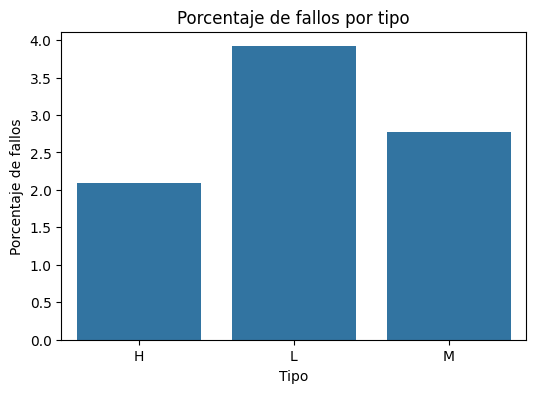

In [41]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=failure_rate_by_type.index,
    y=failure_rate_by_type.values
)

plt.title("Porcentaje de fallos por tipo")
plt.xlabel("Tipo")
plt.ylabel("Porcentaje de fallos")
plt.show()


**Interpretacion:** El tipo `L` presenta el mayor porcentaje de fallos, seguido por `M` y finalmente `H`.

La diferencia no es extrema, pero indica que el tipo de producto o maquina puede aportar informacion al modelo.

**Decision:** La variable `Type` se mantendra como candidata para el modelo. Mas adelante sera necesario transformarla a formato numerico mediante codificacion, ya que los modelos no trabajan directamente con texto.


## Tipos de fallo

En esta seccion se revisan los tipos concretos de fallo incluidos en el dataset.

Estas columnas no se usaran como variables predictoras del modelo principal, pero sirven para entender que clase de problemas aparecen con mas frecuencia.


In [42]:
failure_type_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

failure_type_columns


['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

In [43]:
failure_type_counts = df[failure_type_columns].sum().sort_values(ascending=False)
failure_type_counts


HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

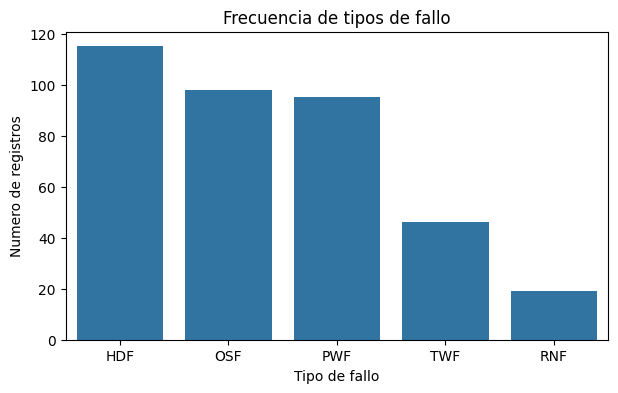

In [44]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=failure_type_counts.index,
    y=failure_type_counts.values
)

plt.title("Frecuencia de tipos de fallo")
plt.xlabel("Tipo de fallo")
plt.ylabel("Numero de registros")
plt.show()


**Interpretacion:** El tipo de fallo mas frecuente es `HDF`, relacionado con la disipacion de calor. Despues aparecen `OSF` y `PWF`, con frecuencias bastante parecidas. Los fallos `TWF` y `RNF` son menos frecuentes.

La suma de los tipos de fallo es mayor que el numero total de registros con `Machine failure = 1`, lo que indica que algunos registros pueden tener mas de un tipo de fallo asociado.

**Decision:** Estas columnas se usaran solo para entender mejor el dataset. No se incluiran como variables predictoras del modelo principal para evitar fuga de informacion.


## Coherencia entre fallo general y tipos de fallo

En esta seccion se revisa si la variable `Machine failure` es coherente con las columnas que indican tipos concretos de fallo.

Esta comprobacion es importante porque puede haber registros con mas de un tipo de fallo o pequenos casos inconsistentes entre el fallo general y el tipo de fallo marcado.


In [45]:
df["failure_type_count"] = df[failure_type_columns].sum(axis=1)


In [46]:
df["failure_type_count"].value_counts().sort_index()


failure_type_count
0    9652
1     324
2      23
3       1
Name: count, dtype: int64

In [47]:
failure_without_type = df[
    (df["Machine failure"] == 1) & 
    (df["failure_type_count"] == 0)
]

failure_without_type.shape[0]


9

In [48]:
type_without_failure = df[
    (df["Machine failure"] == 0) & 
    (df["failure_type_count"] > 0)
]

type_without_failure.shape[0]


18

**Interpretacion:** Se detectan algunas pequeñas incoherencias entre `Machine failure` y las columnas de tipos de fallo. Hay 9 registros donde la maquina aparece como fallida, pero no se indica ningun tipo concreto de fallo. Tambien hay 18 registros donde aparece algun tipo de fallo marcado, aunque `Machine failure` vale 0.

Como son solo 27 registros sobre un total de 10000, no parece un problema importante para esta fase del proyecto.

**Decision:** Se mantiene `Machine failure` como variable objetivo principal y no se modifican estos registros. Las columnas de tipos de fallo seguiran usandose solo como apoyo para entender el dataset, no como variables predictoras.


## Matriz de correlacion

En esta seccion se revisa la correlacion entre las variables numericas principales y la variable objetivo.

La correlacion ayuda a detectar relaciones lineales entre variables, aunque no implica causalidad. Es decir, que dos variables se muevan juntas no significa necesariamente que una cause la otra.


In [49]:
correlation_columns = numeric_features + ["Machine failure"]

correlation_columns


['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure']

In [50]:
correlation_matrix = df[correlation_columns].corr()

correlation_matrix


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


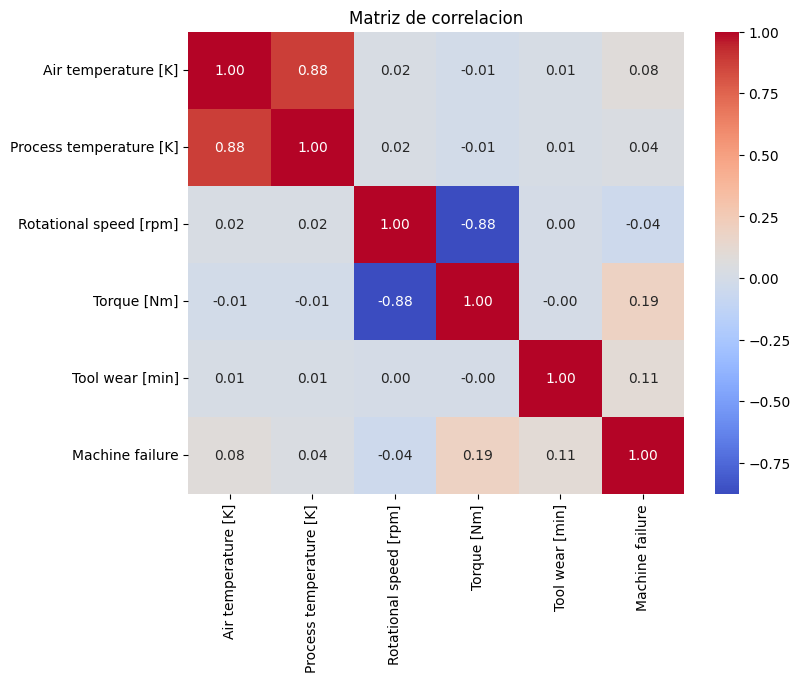

In [51]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlacion")
plt.show()


**Interpretacion:** La matriz de correlacion muestra una relacion alta entre `Air temperature [K]` y `Process temperature [K]`, lo que indica que ambas temperaturas tienden a moverse en la misma direccion.

Tambien se observa una relacion negativa clara entre `Rotational speed [rpm]` y `Torque [Nm]`. Esto tiene sentido en un contexto mecanico: cuando la maquina necesita aplicar mas fuerza de giro, la velocidad puede ser menor.

Respecto a la variable objetivo, `Torque [Nm]` es la variable que muestra mayor relacion con `Machine failure`. `Tool wear [min]` tambien presenta cierta relacion, aunque mas suave. La velocidad de rotacion tiene una relacion negativa debil con el fallo.

**Decision:** Para el modelo se mantendran las variables numericas operativas, prestando especial atencion a `Torque [Nm]`, `Tool wear [min]` y `Rotational speed [rpm]`, ya que parecen aportar informacion util para detectar riesgo de fallo.
